In [14]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

path = "/home/students/studweilc1/MU-Diff/"
# add this to path for imports
if path not in sys.path:
    sys.path.append(path)

import os
import types
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as sk_psnr

from dataset.dataset_dixon import CreateDatasetSynthesis_single, CreateDatasetSynthesis_single_with_masks
from backbones.ncsnpp_generator_adagn_feat_single import NCSNpp, NCSNpp_adaptive

from backbones.dense_layer import conv2d 
from train_utils import (
    get_time_schedule,
    q_sample_pairs,
    sample_posterior,
    sample_from_model, 
    Diffusion_Coefficients,
    Posterior_Coefficients,
    _psnr_torch,
    parse_arguments,
    sample_from_model_single
)

# -------------------------
# Data loader
# -------------------------
def make_loader(args, phase="val", shuffle=False, input_path=None, contrast="T1_mapping_fl2d"):
    """
    Build a DataLoader exactly like in training (DistributedSampler removed for notebook use).
    """
    if input_path is None:
        input_path = args.input_path
    ds = CreateDatasetSynthesis_single(phase=phase, input_path=input_path, contrast=contrast, target_contrast="DIXON")
    loader = torch.utils.data.DataLoader(
        ds,
        batch_size=args.batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=False,
        drop_last=False,
    )
    return loader

def make_loader_with_masks(args, phase="val", shuffle=False, input_path=None, contrast="T1_mapping_fl2d"):
    """
    Build a DataLoader with masks exactly like in training (DistributedSampler removed for notebook use).
    """
    if input_path is None:
        input_path = args.input_path
    
    ds = CreateDatasetSynthesis_single_with_masks(phase=phase, input_path=input_path, contrast=contrast, target_contrast="DIXON")
    loader = torch.utils.data.DataLoader(
        ds,
        batch_size=args.batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=False,
        drop_last=False,
    )
    return loader

# -------------------------
# Model loading
# -------------------------
def _load_state_dict_strict(module, path, map_location):
    sd = torch.load(path, map_location=map_location)
    module.load_state_dict(sd)
    return module

def _load_state_dict_flex(module, src, map_location=None, strict=True):
    """
    Load a state_dict into `module`, handling DDP/DataParallel prefixes ("module.")
    and also accepting either a path or a dict.
    """
    if isinstance(src, str):
        state = torch.load(src, map_location=map_location)
    else:
        state = src

    # Some projects save under 'state_dict'
    if isinstance(state, dict) and 'state_dict' in state and all(
        isinstance(k, str) for k in state['state_dict'].keys()
    ):
        state = state['state_dict']

    try:
        module.load_state_dict(state, strict=strict)
        return
    except RuntimeError as e:
        # Try stripping "module." once
        if isinstance(state, dict) and any(k.startswith('module.') for k in state.keys()):
            stripped = {k.replace('module.', '', 1): v for k, v in state.items()}
            module.load_state_dict(stripped, strict=strict)
            return
        raise e

def load_models(args, ckpt_dir, epoch=None, map_location=None, load_g2=True):
    """
    Load gen_diffusive_1 (and optionally gen_diffusive_2) + sampling helpers.

    Parameters
    ----------
    args : Namespace
        Same args object you use for training (must include num_timesteps, nz, etc.).
    ckpt_dir : str
        Directory with saved checkpoints (e.g., exp_path).
    epoch : int or None
        If provided, loads gen_diffusive_1_{epoch}.pth and gen_diffusive_2_{epoch}.pth.
        If None, tries to load from 'content.pth'.
    map_location : device or str
        e.g., 'cuda:0' or 'cpu'. If None, auto-selects CUDA if available.
    load_g2 : bool
        If False, only loads gen_diffusive_1.

    Returns
    -------
    device, gen1, gen2_or_None, coeff, pos_coeff, T
    """
    if map_location is None:
        map_location = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    device = map_location if isinstance(map_location, torch.device) else torch.device(map_location)

    # Instantiate models exactly like train
    gen1 = NCSNpp(args).to(device).eval()
    gen2 = NCSNpp_adaptive(args).to(device).eval() if load_g2 else None

    # Load weights
    if epoch is not None:
        g1_path = os.path.join(ckpt_dir, f'gen_diffusive_1_{epoch}.pth')
        if not os.path.isfile(g1_path):
            raise FileNotFoundError(f"Missing {g1_path}")
        _load_state_dict_flex(gen1, g1_path, device)

        if load_g2:
            g2_path = os.path.join(ckpt_dir, f'gen_diffusive_2_{epoch}.pth')
            if not os.path.isfile(g2_path):
                raise FileNotFoundError(f"Missing {g2_path}")
            _load_state_dict_flex(gen2, g2_path, device)
    else:
        # fall back to content.pth (latest content snapshot from training)
        content_path = os.path.join(ckpt_dir, 'content.pth')
        if not os.path.isfile(content_path):
            raise FileNotFoundError(f"Provide epoch or ensure {content_path} exists.")
        content = torch.load(content_path, map_location=device)
        gen1.load_state_dict(content['gen_diffusive_1_dict'])
        if load_g2:
            gen2.load_state_dict(content['gen_diffusive_2_dict'])

    # Build sampling helpers exactly as in train
    coeff = Diffusion_Coefficients(args, device)
    pos_coeff = Posterior_Coefficients(args, device)
    T = get_time_schedule(args, device)

    # eval mode, no grads
    gen1.eval()
    if gen2 is not None:
        gen2.eval()
    torch.set_grad_enabled(False)

    return device, gen1, gen2, coeff, pos_coeff, T

# ----------------------------------------
# Predict with gen1 only (single-stage)
# ----------------------------------------
def _sample_from_model_g1_only(pos_coeff, gen1, cond1, cond2, cond3, num_steps, x_t, args):
    """
    Minimal faithful port of the inner loop you use in training:
    at each t, get x0_pred from gen1 and sample posterior to x_{t-1}.
    """
    device = x_t.device
    b = x_t.size(0)
    for i in reversed(range(num_steps)):
        t = torch.full((b,), i, device=device, dtype=torch.long)
        z = torch.randn(b, args.nz, device=device)
        x0_pred = gen1(x_t, cond1, cond2, cond3, t, z)              # shape [B, C(>=1), H, W], take channel 0 like train
        x_t = sample_posterior(pos_coeff, x0_pred[:, [0], :], x_t, t)
    return x_t

# ----------------------------------------
# Unified prediction function
# ----------------------------------------
def predict_sample(
    args,
    device,
    gen1,
    pos_coeff,
    T,
    *,
    gen2=None,
    cond1=None,
    num_timesteps=None,
    x_T=None,
    mode="both",         # "g1" or "both"
    seed=None,
):
    """
    Generate a sample using either only gen1 ("g1") or the two-stage path ("both")
    which calls your original sample_from_model.

    Inputs should be torch tensors already on `device` with shapes matching training:
      cond1, cond2, cond3: [B, 1, H, W] (or whatever your dataset returns)
    """
    assert mode in ("g1", "both"), "mode must be 'g1' or 'both'"

    if seed is not None:
        torch.manual_seed(seed)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(seed)

    if num_timesteps is None:
        num_timesteps = args.num_timesteps

    # Make x_T if not given
    if x_T is None:
        # shape matches real_data from loader (use cond1’s shape for convenience)
        x_T = torch.randn_like(cond1)

    if mode == "both":
        if gen2 is None:
            raise ValueError("mode='both' requires gen2.")
        # Use the exact helper from training to ensure behavior parity
        out = sample_from_model_single(
            pos_coeff,
            gen1, cond1,
            gen2,
            num_timesteps,
            x_T, T, args
        )
        return out

    else:  # "g1"
        out = _sample_from_model_g1_only(
            pos_coeff,
            gen1,
            cond1,
            num_timesteps,
            x_T,
            args
        )
        return out

# ----------------------------------------
# Evaluation (exactly like validation loop)
# ----------------------------------------
def _to_range_0_1(x):
    return (x + 1.) / 2.

def eval_l1_psnr(fake, real, also_other_psnr=True):
    """
    Reproduces your validation metrics:
      - Convert to [0,1]
      - (a) divide-by-mean version
      - (b) without mean normalization
      - optional _psnr_torch just like the try/except in val loop

    Inputs: fake, real  (torch tensors, same shape)
    Returns dict of floats.
    """
    with torch.no_grad():
        fake_01 = _to_range_0_1(fake)
        real_01 = _to_range_0_1(real)

        # a) mean-normalized
        fake_div = fake_01 / fake_01.mean()
        real_div = real_01 / real_01.mean()

        fake_div_np = fake_div.detach().cpu().numpy()
        real_div_np = real_div.detach().cpu().numpy()
        l1_div = float(np.abs(fake_div_np - real_div_np).mean())
        psnr_div = float(sk_psnr(real_div_np, fake_div_np, data_range=real_div_np.max()))

        # b) without mean normalization
        fake_np = fake_01.detach().cpu().numpy()
        real_np = real_01.detach().cpu().numpy()
        l1_wmean = float(np.abs(fake_np - real_np).mean())
        psnr_wmean = float(sk_psnr(real_np, fake_np, data_range=real_np.max()))

        other_psnr = None
        if also_other_psnr:
            try:
                other_psnr = float(_psnr_torch(fake_01, real_01))
            except Exception:
                other_psnr = -1.0

    return {
        "l1_mean_norm": l1_div,
        "psnr_mean_norm": psnr_div,
        "l1_without_mean": l1_wmean,
        "psnr_without_mean": psnr_wmean,
        "psnr_other_fn": other_psnr,
    }

# ----------------------------------------
# Small convenience to fetch a single batch from a loader
# ----------------------------------------
def get_one_batch(loader, device):
    """
    Returns (cond1, cond2, cond3, gt) on device from the first batch.
    """
    batch = next(iter(loader))
    x1, x2, x3, x4 = batch
    return (
        x1.to(device, non_blocking=True),
        x2.to(device, non_blocking=True),
        x3.to(device, non_blocking=True),
        x4.to(device, non_blocking=True),
    )


def load_args_from_content(ckpt_dir, map_location='cpu'):
    """
    Load the saved args Namespace from a training content.pth file.

    Parameters
    ----------
    ckpt_dir : str
        Path to experiment directory (contains content.pth).
    map_location : str or torch.device
        Device for torch.load (args are just CPU objects, but safe to set).

    Returns
    -------
    args : argparse.Namespace
        The exact arguments object used during training.
    """
    content_path = os.path.join(ckpt_dir, "content.pth")
    if not os.path.isfile(content_path):
        raise FileNotFoundError(f"No content.pth in {ckpt_dir}")

    content = torch.load(content_path, map_location=map_location, weights_only=False)
    return content["args"]

# ===== Example usage in a notebook (adjust paths/args) =====
# args, _ = parse_arguments()    # or build your args Namespace manually for a notebook
# device, g1, g2, coeff, pos_coeff, T = load_models(args, ckpt_dir="/path/to/exp", epoch=100, load_g2=True)
# val_loader = make_loader(args, phase="val", shuffle=False)
# c1, c2, c3, gt = get_one_batch(val_loader, device)
#
# # --- two-stage prediction (same as training logs) ---
# x_T = torch.randn_like(gt)
# pred_both = predict_sample(args, device, g1, pos_coeff, T, gen2=g2, cond1=c1, cond2=c2, cond3=c3, x_T=x_T, mode="both")
# metrics_both = eval_l1_psnr(pred_both, gt)
#
# # --- gen1-only prediction ---
# x_T = torch.randn_like(gt)
# pred_g1 = predict_sample(args, device, g1, pos_coeff, T, gen2=None, cond1=c1, cond2=c2, cond3=c3, x_T=x_T, mode="g1")
# metrics_g1 = eval_l1_psnr(pred_g1, gt)
#
# print(metrics_both)
# print(metrics_g1)


In [5]:
args = load_args_from_content("../results/exp_brats_single_T1")
device, g1, g2, coeff, pos_coeff, T = load_models(args, ckpt_dir="../results/exp_brats_single_T1", epoch=20, load_g2=True)
val_loader = make_loader_with_masks(args, phase="val", shuffle=False, input_path="../data/my_data2", contrast="T1_mapping_fl2d")
#train_loader = make_loader_with_masks(args, phase="train", shuffle=False, input_path="../data/my_data2")
#test_loader = make_loader_with_masks(args, phase="test", shuffle=False, input_path="../data/my_data2")

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [7]:
# --- !! PRINT THE MODULES TO FIND YOUR LAYER !! ---
# print("===== Gen 1 Modules =====")
print(g1.all_modules)

ModuleList(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): Linear(in_features=256, out_features=256, bias=True)
  (2-3): 2 x ConvFeatBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (group_norm): GroupNorm_Conv(
      (norm): GroupNorm(16, 64, eps=1e-06, affine=False)
    )
    (act): SiLU()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (4): ResnetBlockBigGANpp_Adagn(
    (GroupNorm_0): AdaptiveGroupNorm(
      (norm): GroupNorm(32, 128, eps=1e-06, affine=False)
      (style): Linear(in_features=256, out_features=256, bias=True)
    )
    (Conv_0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (Dense_0): Linear(in_features=256, out_features=64, bias=True)
    (GroupNorm_1): AdaptiveGroupNorm(
      (norm): GroupNorm(16, 64, eps=1e-06, affine=False)
      (style): Linear(in_features=256, out_features=128, bias=True)
    )
    (Dropout_0): Dropout(p=0.0, inplace=Fals

In [9]:
index=10
c1,target,m1,m_target = val_loader.dataset[index]
c1 = c1.unsqueeze(0).to(device)
target = target.unsqueeze(0).to(device)
x_T = torch.randn_like(target)
m1 = m1.unsqueeze(0).to(device)
m_target = m_target.unsqueeze(0).to(device)
# create blank version for c1
c1_blank = torch.zeros_like(c1)

In [18]:
def get_features(name, features_dict):
    """
    Returns a hook function that saves the output of a module
    to the provided `features_dict` with the key `name`.
    """
    def hook(model, input, output):
        # We detach the output tensor to prevent it from
        # being part of the computation graph (saves memory)
        features_dict[name] = output.detach()
    return hook


def extract_features(c1, target, args, g1, pos_coeff, T):
    FEAT_LAYER_C1 = 3 
    BOTTLENECK_LAYER_IDX = 16  # Example: Hooking a deep ResnetBlock
    MIDDLE_LAYER_IDX = 10

    features = {}

    # A "handle" is returned, which we use to remove the hook later
    handle_c1 = g1.all_modules[FEAT_LAYER_C1].register_forward_hook(
        get_features('g1_c1_feat', features_dict=features)
    )

    handle_middle = g1.all_modules[MIDDLE_LAYER_IDX].register_forward_hook(
        get_features('g1_middle', features_dict=features)
    )

    handle_bottleneck = g1.all_modules[BOTTLENECK_LAYER_IDX].register_forward_hook(
        get_features('g1_bottleneck', features_dict=features)
    )

    # --- 4. Run prediction (G1-only mode) ---
    # The hooks will automatically run during this forward pass
    print("Running G1 prediction...")
    x_T = torch.randn_like(target)
    pred_g1 = predict_sample(
        args, device, g1, pos_coeff, T, 
        gen2=g2, cond1=c1, 
        x_T=x_T, mode="both"
    )
    feature_c1 = features['g1_c1_feat']
    feature_middle = features['g1_middle']
    feature_bottleneck = features['g1_bottleneck']
    handle_c1.remove()
    handle_middle.remove()
    handle_bottleneck.remove()
    features.clear()
    return feature_c1, feature_middle, feature_bottleneck, pred_g1

In [20]:
feature_c1_target, feature_middle_target, feature_bottleneck_target, pred_g1_target = extract_features(target, target, args, g1, pos_coeff, T)
feature_c1, feature_middle, feature_bottleneck, pred_g1 = extract_features(c1, target, args, g1, pos_coeff, T)

Running G1 prediction...
Running G1 prediction...


Text(0.5, 1.0, 'target')

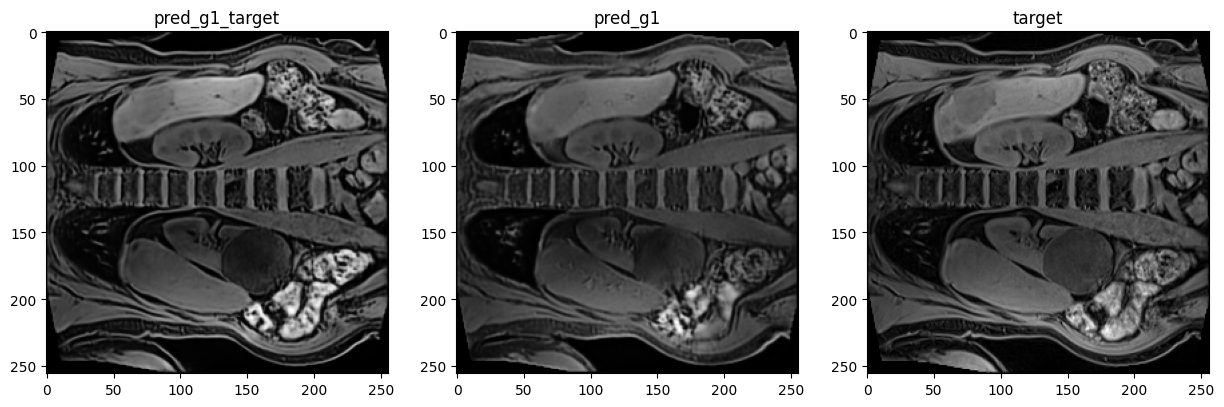

In [21]:
#1. show predictions
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(pred_g1_target[0,0].cpu(), cmap='gray')
ax[0].set_title('pred_g1_target')
ax[1].imshow(pred_g1[0,0].cpu(), cmap='gray')
ax[1].set_title('pred_g1')
ax[2].imshow(target[0,0].cpu(), cmap='gray')
ax[2].set_title('target')

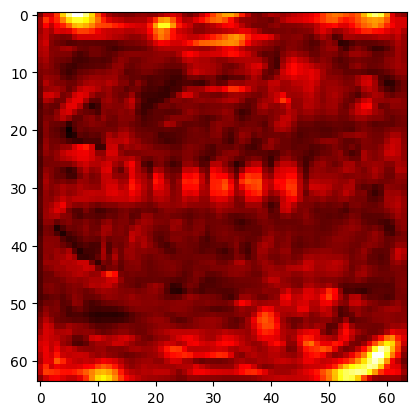

In [30]:
feat_target_map = feature_middle_target.squeeze(0)
feat_c1_map = feature_middle.squeeze(0)

C, H, W = feat_target_map.shape

# Pick a query point
y, x = 20,5

# Get the feature vector at that point
query_vector = feat_target_map[:, y, x]  # Shape [C]

# Reshape query_vector to [C, 1, 1] for broadcasting
query_vec_reshaped = query_vector.view(C, 1, 1)

# Calculate L2 (Euclidean) distance
# This subtracts the query vector from every vector in the c1 map
# and computes the norm along the channel dimension.
dist_map = torch.norm(feat_c1_map - query_vec_reshaped, p=2, dim=0) # Shape [H, W]

plt.imshow(dist_map.cpu(), cmap='hot')

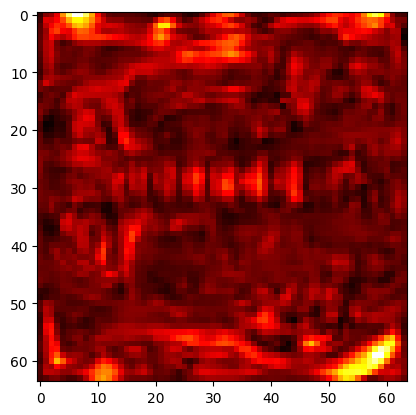

In [29]:
feat_target_map = feature_middle_target.squeeze(0)
feat_c1_map = feature_middle.squeeze(0)

C, H, W = feat_target_map.shape

# 1. Pick a meaningful point from your ORIGINAL IMAGE
y_img, x_img = 52, 160 

# 2. Calculate the corresponding point in the feature map
# (Assuming 4x downsampling for Layer 16)
scaling_factor = 4
y_feat = y_img // scaling_factor
x_feat = x_img // scaling_factor

# 3. Get the feature vector at that scaled point
query_vector = feat_target_map[:, y_feat, x_feat]

# Reshape query_vector to [C, 1, 1] for broadcasting
query_vec_reshaped = query_vector.view(C, 1, 1)

# Calculate L2 (Euclidean) distance
# This subtracts the query vector from every vector in the c1 map
# and computes the norm along the channel dimension.
dist_map = torch.norm(feat_c1_map - query_vec_reshaped, p=2, dim=0) # Shape [H, W]

plt.imshow(dist_map.cpu(), cmap='hot')

## Test Feature based registration 

In [58]:
from typing import Tuple
from scipy.ndimage import gaussian_filter
import torch.nn.functional as F
from torchvision.transforms import GaussianBlur
from scipy.ndimage import binary_closing, binary_fill_holes

import pandas as pd
import matplotlib.colors as mcolors
import h5py
from monai.metrics import DiceMetric
dice_metric = DiceMetric(include_background=True, reduction="mean")


def estimate_and_fill_mask(image_tensor: torch.Tensor, background_threshold: float = 0.05) -> torch.Tensor:
    """
    Estimates a foreground mask from an image and fills holes.
    """
    # Create initial mask by thresholding
    initial_mask = (image_tensor > background_threshold).squeeze().cpu().numpy()
    
    # Use binary closing to fill small gaps and connect nearby components
    closed_mask = binary_closing(initial_mask, structure=np.ones((5,5)), iterations=2)
    
    # Use binary fill holes to fill any holes inside the main object
    filled_mask = binary_fill_holes(closed_mask)
    
    # Convert back to a tensor
    mask_tensor = torch.from_numpy(filled_mask).float().unsqueeze(0).unsqueeze(0).to(image_tensor.device)
    
    return mask_tensor


def calculate_all_correspondences(
    image_a_tensor: torch.Tensor,
    image_b_tensor: torch.Tensor,
    features_a: torch.Tensor,
    features_b: torch.Tensor,
    k: int = 5,
    image_size: int = 256,
    device: str = "cpu",
    max_distance: int = None
) -> Tuple[np.ndarray, np.ndarray, torch.Tensor]:
    """
    Calculates top-k correspondences using global search then filters by distance.
    """
    H, W = image_size, image_size
    with torch.no_grad():
        mask_a = estimate_and_fill_mask(image_a_tensor)
        mask_b = estimate_and_fill_mask(image_b_tensor)

        features_a_resized = F.interpolate(features_a, size=(H, W), mode='bilinear', align_corners=False)
        features_b_resized = F.interpolate(features_b, size=(H, W), mode='bilinear', align_corners=False)

        C = features_a_resized.shape[1]
        
        fg_indices_b = torch.nonzero(mask_b.view(-1)).squeeze()
        if fg_indices_b.numel() == 0:
            raise ValueError("Mask for Image B is completely black.")
            
        features_b_flat = features_b_resized.view(C, -1)
        features_b_fg = features_b_flat[:, fg_indices_b]
        features_b_fg_norm = F.normalize(features_b_fg, p=2, dim=0)
        
        grid_y, grid_x = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
        identity_coords = torch.stack([grid_y, grid_x], dim=-1).unsqueeze(2).expand(-1, -1, k, -1)
        
        coords_map = identity_coords.clone()
        certainty_map = torch.zeros((H, W, k), device=device)
        certainty_map[:,:,0] = 1.0

        fg_indices_a = torch.nonzero(mask_a.squeeze())
        
        features_a_flat = features_a_resized.view(C, -1)
        features_a_fg = features_a_flat[:, mask_a.view(-1) > 0]
        features_a_fg_norm = F.normalize(features_a_fg, p=2, dim=0)
        
        sim_matrix = features_a_fg_norm.T @ features_b_fg_norm
        
        top_k_scores, top_k_relative_indices = torch.topk(sim_matrix, k, dim=1)
        
        top_k_global_indices = fg_indices_b[top_k_relative_indices]
        
        match_y = top_k_global_indices // W
        match_x = top_k_global_indices % W
        
        match_coords = torch.stack([match_y, match_x], dim=-1)

        if max_distance is not None:
            fg_coords_a = fg_indices_a.unsqueeze(1).expand(-1, k, -1)
            distances_sq = torch.sum((match_coords.float() - fg_coords_a.float())**2, dim=-1)
            invalid_mask = distances_sq > max_distance**2
            top_k_scores[invalid_mask] = -torch.inf

        all_invalid_mask = torch.all(top_k_scores == -torch.inf, dim=1)
        valid_fg_indices_a = fg_indices_a[~all_invalid_mask]
        
        coords_map[valid_fg_indices_a[:, 0], valid_fg_indices_a[:, 1]] = match_coords[~all_invalid_mask]
        
        valid_scores = top_k_scores[~all_invalid_mask]
        if valid_scores.numel() > 0:
             certainty_map[valid_fg_indices_a[:, 0], valid_fg_indices_a[:, 1]] = F.softmax(valid_scores, dim=-1)

    return coords_map.cpu().numpy(), certainty_map.cpu().numpy(), mask_a.cpu()


def create_warping(
    image_a_tensor: torch.Tensor,
    mask_a: torch.Tensor,
    correspondence_map: np.ndarray,
    certainty_map: np.ndarray,
    top_k_to_use: int = 3,
    use_certainty_weights: bool = True,
    distance_lambda: float = 50.0,
    smoothing_sigma: float = 5.0,
    estimation_method: str = 'mean'
) -> np.ndarray:
    """
    Creates a warped image A based on correspondences, respecting a mask.
    """
    H, W, k_max, _ = correspondence_map.shape
    device = image_a_tensor.device
    
    mask_a = mask_a.squeeze().to(device) # Shape [H, W]

    k = min(top_k_to_use, k_max)
    coords = torch.from_numpy(correspondence_map[:, :, :k, :]).float().to(device)
    certainties = torch.from_numpy(certainty_map[:, :, :k]).float().to(device)

    grid_y, grid_x = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
    identity_grid = torch.stack([grid_y, grid_x], dim=-1)

    identity_grid_expanded = identity_grid.unsqueeze(2).expand(-1, -1, k, -1)
    distances_sq = torch.sum((identity_grid_expanded - coords)**2, dim=-1)
    distance_weights = torch.exp(-distances_sq / (2 * distance_lambda**2))

    if use_certainty_weights:
        final_weights = certainties * distance_weights
    else:
        final_weights = distance_weights
    
    if estimation_method == 'mean':
        normalized_weights = final_weights / (final_weights.sum(dim=-1, keepdim=True) + 1e-8)
        target_coords = torch.sum(coords * normalized_weights.unsqueeze(-1), dim=2)
    elif estimation_method == 'median':
        target_coords = torch.median(coords, dim=2).values
    elif estimation_method == 'best_match':
        best_match_idx = torch.argmax(final_weights, dim=-1, keepdim=True)
        best_match_idx_expanded = best_match_idx.unsqueeze(-1).expand(-1, -1, -1, 2)
        target_coords = torch.gather(coords, 2, best_match_idx_expanded).squeeze(2)
    else:
        raise ValueError("estimation_method must be one of 'mean', 'median', or 'best_match'")

    mask_expanded = mask_a.unsqueeze(-1).expand_as(target_coords)
    target_coords = torch.where(mask_expanded.bool(), target_coords, identity_grid)
    
    if smoothing_sigma > 0:
        kernel_size = 2 * int(3.5 * smoothing_sigma) + 1
        smoother = GaussianBlur(kernel_size=kernel_size, sigma=smoothing_sigma)
        target_coords_permuted = target_coords.permute(2, 0, 1)
        smoothed_coords_permuted = smoother(target_coords_permuted)
        target_coords = smoothed_coords_permuted.permute(1, 2, 0)

    grid_for_sampling = target_coords.clone()
    grid_for_sampling[..., 0] = 2.0 * grid_for_sampling[..., 0] / (H - 1) - 1.0
    grid_for_sampling[..., 1] = 2.0 * grid_for_sampling[..., 1] / (W - 1) - 1.0
    grid_for_sampling = grid_for_sampling.flip(-1).unsqueeze(0)

    warped_tensor = F.grid_sample(
        image_a_tensor, grid_for_sampling, mode='bilinear', padding_mode='border', align_corners=True
    )
    
    warped_tensor *= mask_a.view(1, 1, H, W)

    warped_image_np = warped_tensor.squeeze().cpu().numpy() * 255
    return warped_image_np.astype(np.uint8)

def create_flow_field(
    mask_a: torch.Tensor,
    correspondence_map: np.ndarray,
    certainty_map: np.ndarray,
    top_k_to_use: int = 3,
    use_certainty_weights: bool = True,
    distance_lambda: float = 50.0,
    smoothing_sigma: float = 5.0,
    estimation_method: str = 'mean'
) -> torch.Tensor:
    """
    Creates a deformation field (flow field) from correspondence data.

    Returns:
        torch.Tensor: A tensor of shape (H, W, 2) representing the flow field.
    """
    H, W, k_max, _ = correspondence_map.shape
    device = mask_a.device
    
    mask_a = mask_a.squeeze() # Shape [H, W]

    k = min(top_k_to_use, k_max)
    coords = torch.from_numpy(correspondence_map[:, :, :k, :]).float().to(device)
    certainties = torch.from_numpy(certainty_map[:, :, :k]).float().to(device)

    grid_y, grid_x = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
    identity_grid = torch.stack([grid_y, grid_x], dim=-1)

    identity_grid_expanded = identity_grid.unsqueeze(2).expand(-1, -1, k, -1)
    distances_sq = torch.sum((identity_grid_expanded - coords)**2, dim=-1)
    distance_weights = torch.exp(-distances_sq / (2 * distance_lambda**2))

    if use_certainty_weights:
        final_weights = certainties * distance_weights
    else:
        final_weights = distance_weights
    
    if estimation_method == 'mean':
        normalized_weights = final_weights / (final_weights.sum(dim=-1, keepdim=True) + 1e-8)
        target_coords = torch.sum(coords * normalized_weights.unsqueeze(-1), dim=2)
    elif estimation_method == 'median':
        target_coords = torch.median(coords, dim=2).values
    elif estimation_method == 'best_match':
        best_match_idx = torch.argmax(final_weights, dim=-1, keepdim=True)
        best_match_idx_expanded = best_match_idx.unsqueeze(-1).expand(-1, -1, -1, 2)
        target_coords = torch.gather(coords, 2, best_match_idx_expanded).squeeze(2)
    else:
        raise ValueError("estimation_method must be one of 'mean', 'median', or 'best_match'")

    mask_expanded = mask_a.unsqueeze(-1).expand_as(target_coords)
    target_coords = torch.where(mask_expanded.bool(), target_coords, identity_grid)
    
    if smoothing_sigma > 0:
        kernel_size = 2 * int(3.5 * smoothing_sigma) + 1
        smoother = GaussianBlur(kernel_size=kernel_size, sigma=smoothing_sigma)
        target_coords_permuted = target_coords.permute(2, 0, 1)
        smoothed_coords_permuted = smoother(target_coords_permuted)
        target_coords = smoothed_coords_permuted.permute(1, 2, 0)

    return target_coords

def apply_flow_field(
    input_tensor: torch.Tensor,
    flow_field: torch.Tensor,
    interpolation_mode: str = 'bilinear'
) -> np.ndarray:
    """
    Applies a pre-computed flow field to warp an image or mask.
    
    Args:
        input_tensor (torch.Tensor): The image/mask to warp, shape [1, 1, H, W].
        flow_field (torch.Tensor): The deformation field, shape [H, W, 2].
        interpolation_mode (str): 'bilinear' for images, 'nearest' for masks.
        
    Returns:
        np.ndarray: The warped image/mask as a NumPy array.
    """
    H, W, _ = flow_field.shape
    device = input_tensor.device
    flow_field = flow_field.to(device)

    # Normalize flow field coordinates from pixel space [0, H-1] to sample space [-1, 1]
    grid_for_sampling = flow_field.clone()
    grid_for_sampling[..., 0] = 2.0 * grid_for_sampling[..., 0] / (H - 1) - 1.0
    grid_for_sampling[..., 1] = 2.0 * grid_for_sampling[..., 1] / (W - 1) - 1.0
    grid_for_sampling = grid_for_sampling.flip(-1).unsqueeze(0) # Flip to (x, y) and add batch dim

    warped_tensor = F.grid_sample(
        input_tensor, grid_for_sampling, mode=interpolation_mode, padding_mode='zeros', align_corners=True
    )
    
    #warped_np = warped_tensor.squeeze().cpu().numpy() * 255
    #return warped_np.astype(np.uint8)
    return warped_tensor

def visualize_pixel_correspondences(
    image_a_np: np.ndarray,
    image_b_np: np.ndarray,
    coords_map: np.ndarray, # Assumes pixel-based [H,W,k,2]
    cert_map: np.ndarray,   # Assumes pixel-based [H,W,k]
    point_a_yx: Tuple[int, int],
    distance_lambda: float = 50.0,
    use_certainty_weights: bool = True
):
    """
    Visualizes the top-k pixel matches and estimated points for a single point.
    Takes NumPy arrays as image inputs.
    """
    H, W, k_max, _ = coords_map.shape
    device = 'cpu' # Calculations are fast enough

    y_a, x_a = point_a_yx
    top_k_coords_b = torch.from_numpy(coords_map[y_a, x_a]).float().to(device) # [k, 2]
    top_k_certs = torch.from_numpy(cert_map[y_a, x_a]).float().to(device)     # [k]
    source_point_for_dist = torch.tensor([y_a, x_a], dtype=torch.float, device=device) # [2]

    k = top_k_coords_b.shape[0]
    print(f"Top {k} matches for point {point_a_yx} in Image B:")

    # --- Re-calculate weights and estimated points ---
    source_point_expanded = source_point_for_dist.unsqueeze(0).expand(k, -1) # [k, 2]
    distances_sq = torch.sum((source_point_expanded - top_k_coords_b)**2, dim=-1) # [k]
    distance_weights = torch.exp(-distances_sq / (2 * distance_lambda**2)) # [k]

    if use_certainty_weights:
        final_weights = top_k_certs * distance_weights
    else:
        final_weights = distance_weights
        
    valid_weights_mask = final_weights > 1e-8 # Use only valid matches

    # Mean calculation
    if valid_weights_mask.any():
        normalized_weights = final_weights[valid_weights_mask] / final_weights[valid_weights_mask].sum()
        mean_coord = torch.sum(top_k_coords_b[valid_weights_mask] * normalized_weights.unsqueeze(-1), dim=0)
    else:
        mean_coord = source_point_for_dist

    # Median calculation (ignores weights)
    if k > 0 and valid_weights_mask.any():
        median_coord = torch.median(top_k_coords_b[valid_weights_mask], dim=0).values
    else:
        median_coord = source_point_for_dist

    # Best Match calculation
    if valid_weights_mask.any():
        # Ensure that the index is chosen from valid weights only
        best_match_idx_local = torch.argmax(final_weights[valid_weights_mask])
        original_indices = torch.nonzero(valid_weights_mask).squeeze()
        # Handle scalar case if only one valid weight
        if original_indices.numel() == 1:
            best_match_idx_global = original_indices
        else:
             best_match_idx_global = original_indices[best_match_idx_local]
        best_match_coord = top_k_coords_b[best_match_idx_global]
    else:
        best_match_coord = source_point_for_dist

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    axes[0].imshow(image_a_np, cmap='gray')
    axes[0].set_title(f"Image A - Point ({point_a_yx[1]}, {point_a_yx[0]})")
    #axes[0].axis('off')
    # Plot source point (x, y order for matplotlib) using scatter
    axes[0].scatter(point_a_yx[1], point_a_yx[0], c='white', marker='+', s=50, linewidths=1, label='Source Point')
    axes[0].legend()

    axes[1].imshow(image_b_np, cmap='gray')
    axes[1].set_title("Image B - Correspondences & Estimates")
    #axes[1].axis('off')

    # Plot top k raw matches (x, y order) using scatter
    print(top_k_coords_b)
    valid_coords_b_np = top_k_coords_b[valid_weights_mask].cpu().numpy()
    if valid_coords_b_np.shape[0] > 0:
        axes[1].scatter(valid_coords_b_np[:, 1], valid_coords_b_np[:, 0], c='white', marker='o', s=50, label='Top-k Matches', alpha=0.8, edgecolors='black')

    # Plot estimated points (x, y order) using scatter
    #axes[1].scatter(best_match_coord[1].item(), best_match_coord[0].item(), c='red', marker='x', s=150, linewidths=2, label='Best Match (Weighted)')
    #axes[1].scatter(mean_coord[1].item(), mean_coord[0].item(), c='blue', marker='+', s=150, linewidths=2, label='Mean (Weighted)')
    #axes[1].scatter(median_coord[1].item(), median_coord[0].item(), c='lime', marker='*', s=150, linewidths=2, label='Median') # Changed to lime for better visibility

    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [32]:
index=10
c1,target,m1,m_target = val_loader.dataset[index]
c1 = c1.unsqueeze(0).to(device)
target = target.unsqueeze(0).to(device)
x_T = torch.randn_like(target)
m1 = m1.unsqueeze(0).to(device)
m_target = m_target.unsqueeze(0).to(device)
# create blank version for c1
c1_blank = torch.zeros_like(c1)

feature_c1_target, feature_middle_target, feature_bottleneck_target, pred_g1_target = extract_features(target, target, args, g1, pos_coeff, T)
feature_c1, feature_middle, feature_bottleneck, pred_g1 = extract_features(c1, target, args, g1, pos_coeff, T)

Running G1 prediction...
Running G1 prediction...


In [36]:
def transform_to_0_1(image):
    min_val = image.min()
    max_val = image.max()
    normalized_image = (image - min_val) / (max_val - min_val + 1e-8)
    return normalized_image

c1_n = transform_to_0_1(c1)
target_n = transform_to_0_1(target)

In [69]:
coords_map, cert_map, mask_a = calculate_all_correspondences(c1_n, target_n, feature_middle, feature_middle_target, k=5, image_size=256, device=device, max_distance=200)

Applying flow field to Image A...
Applying flow field to Mask A...


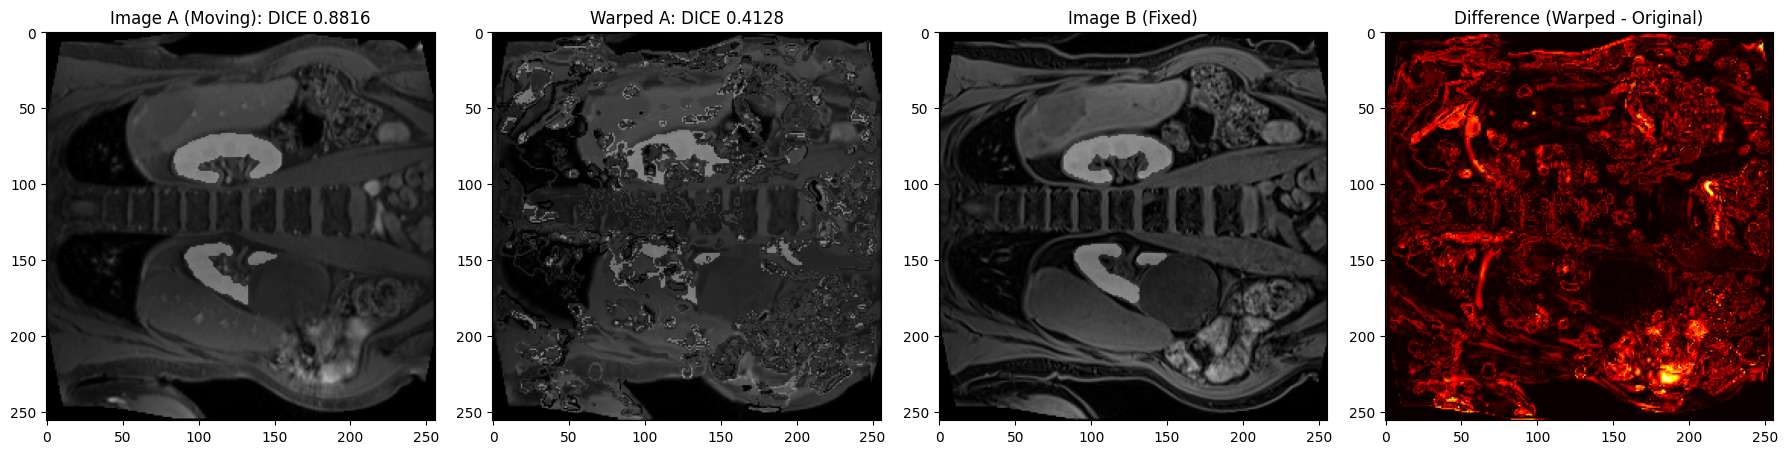

In [70]:
flow_field = create_flow_field(
        mask_a,
        coords_map,
        cert_map,
        top_k_to_use=5,
        use_certainty_weights=True,
        distance_lambda=10.0,
        smoothing_sigma=1,
        estimation_method='best_match'
        )
        

print("Applying flow field to Image A...")
warped_t1_image = apply_flow_field(c1_n, flow_field, interpolation_mode='bilinear')

print("Applying flow field to Mask A...")
# Note the use of 'nearest' interpolation for the mask
warped_mask = apply_flow_field(m1, flow_field, interpolation_mode='nearest')

org_dice = float(dice_metric(m_target, m1))
warped_dice = float(dice_metric(warped_mask, m_target))

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(c1_n.squeeze().cpu().numpy(), cmap='gray')
axes[0].imshow(m1.squeeze().cpu().numpy(), alpha=0.3, cmap='gray')
axes[0].set_title("Image A (Moving): DICE {:.4f}".format(org_dice))
#axes[0].axis('off')

axes[1].imshow(warped_t1_image.squeeze().cpu().numpy(), cmap='gray')
axes[1].imshow(warped_mask.squeeze().cpu().numpy(), alpha=0.3, cmap='gray')
axes[1].set_title("Warped A: DICE {:.4f}".format(warped_dice))
#axes[1].axis('off')

axes[2].imshow(target_n.squeeze().cpu().numpy(), cmap='gray')
axes[2].imshow(m_target.squeeze().cpu().numpy(), alpha=0.3, cmap='gray')
axes[2].set_title("Image B (Fixed)")
#axes[2].axis('off')

# show difference warped and original t1
axes[3].imshow(np.abs(warped_t1_image.squeeze().cpu().numpy() - c1_n.squeeze().cpu().numpy()), cmap='hot')
axes[3].set_title("Difference (Warped - Original)")

plt.tight_layout()
plt.show()

Top 5 matches for point (80, 200) in Image B:
tensor([[48., 64.],
        [46., 67.],
        [47., 65.],
        [45., 68.],
        [47., 64.]])


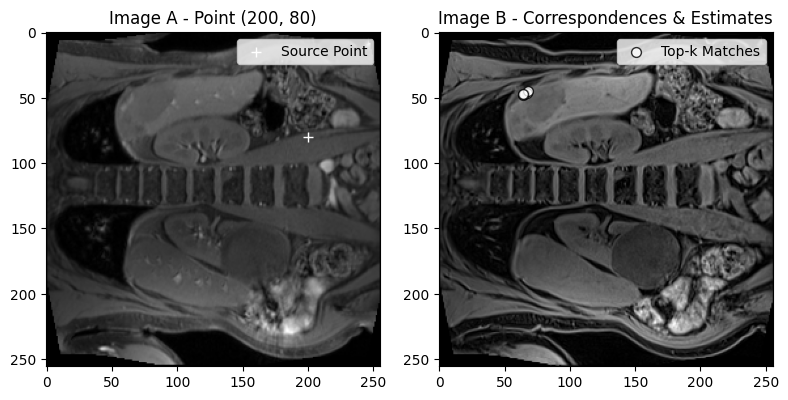

In [72]:
visualize_pixel_correspondences(c1_n.squeeze().cpu().numpy(), target_n.squeeze().cpu().numpy(), coords_map, cert_map, point_a_yx=(80, 200))